# TP 1 — scikit-image : filtres, morphologie, segmentation

**Objectifs**

- Comparer plusieurs filtres de débruitage (gaussien, médian, bilatéral) face à du bruit poivre-et-sel et gaussien.
- Nettoyer un masque binaire avec les opérateurs morphologiques (ouverture, fermeture).
- Compter automatiquement les objets d'une image avec Otsu + `regionprops`.

**Durée indicative : 50 minutes.**

Text(0.5, 1.0, 'Image originale')

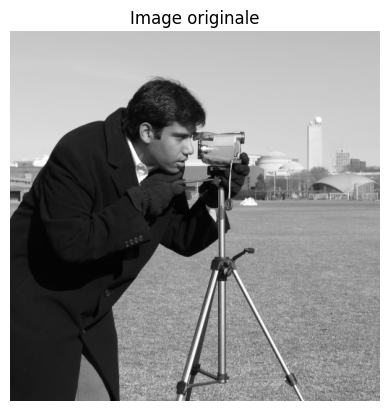

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import color, data, filters, measure, morphology, util
from skimage.util import img_as_float, img_as_ubyte

rng = np.random.default_rng(0)

img = data.camera()  # niveaux de gris 512x512, uint8
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("Image originale")

## Exercice 1 — Bruit et débruitage

1. Créez deux versions bruitées de `img` :
   - `img_sp` : bruit poivre-et-sel (`util.random_noise(img, mode='s&p', amount=0.05)`).
   - `img_g`  : bruit gaussien (`util.random_noise(img, mode='gaussian', var=0.01)`).
   - Attention : `random_noise` renvoie du float dans `[0, 1]`.
2. Appliquez sur chaque version trois filtres :
   - gaussien (`filters.gaussian`, σ=1.5),
   - médian (`filters.median`, élément structurant disque rayon 2),
   - bilatéral (`skimage.restoration.denoise_bilateral`).
3. Affichez les résultats sur deux figures 1×4 (originale bruitée + 3 filtres). Commentez : quel filtre est le mieux adapté à quel bruit ?

<details>
<summary>💡 Coup de pouce — bruit, débruitage, et les types</summary>

**🎯 But :** ajouter du bruit synthétique, puis tester 3 filtres de débruitage. Le piège récurrent : les **types de données** (float vs uint8) qui changent entre les fonctions skimage.

**Ajouter du bruit**

```python
from skimage import util
noisy = util.random_noise(img, mode="gaussian", var=0.01)
```

⚠️ `random_noise` retourne du **float dans [0, 1]**, même si l'entrée était en uint8 [0, 255]. C'est une convention scikit-image (« tout en float [0, 1] »). Pour repasser en uint8 :

```python
noisy_u8 = util.img_as_ubyte(noisy)
```

**Filtre médian**

```python
from skimage.filters import median
from skimage.morphology import disk
clean = median(noisy_u8, footprint=disk(2))
```

- `footprint` = la **fenêtre** dans laquelle on prend la médiane (équivalent du kernel pour les filtres linéaires).
- `disk(2)` = disque de rayon 2 px (≈ 13 pixels actifs).
- Excellent contre le bruit **« sel et poivre »** (pixels isolés très clairs ou sombres). Inefficace contre le bruit gaussien.

**Filtre bilatéral**

```python
from skimage.restoration import denoise_bilateral
clean = denoise_bilateral(noisy, sigma_color=0.05, sigma_spatial=2)
```

- `sigma_color` : tolérance sur les **différences d'intensité** (un voisin éloigné en valeur compte moins).
- `sigma_spatial` : tolérance sur les **distances spatiales** (voisin éloigné en pixels compte moins).
- Préserve les contours nets contrairement au gaussien qui flouait tout uniformément.

**Filtre gaussien**

```python
from skimage.filters import gaussian
clean = gaussian(noisy, sigma=1.5)
```

Simple, rapide, **mais flou les contours en même temps que le bruit**. À éviter si on veut garder les arêtes.

**Récap quoi utiliser quand**

| Type de bruit | Filtre recommandé |
|---|---|
| Gaussien (capteur, faible lumière) | bilatéral |
| Impulsions / sel-poivre | médian |
| Léger / on veut juste lisser | gaussien |

</details>

In [2]:
# TODO

## Exercice 2 — Morphologie sur un masque binaire

L'image `data.coins()` contient une vingtaine de pièces sur fond clair.

1. Calculez un masque binaire en seuillant avec Otsu (`filters.threshold_otsu`).
2. Affichez le masque brut. Vous verrez probablement des trous et des petits points parasites.
3. Appliquez :
   - une **ouverture** avec un disque de rayon 2 pour enlever les points isolés,
   - puis une **fermeture** avec un disque de rayon 5 pour boucher les trous internes.
4. Affichez les 3 masques côte à côte (brut, après ouverture, après fermeture).

<details>
<summary>💡 Coup de pouce — segmentation par Otsu + nettoyage morpho</summary>

**🎯 But :** transformer une image grise en masque binaire **propre** (sans trous, sans bruit isolé), prêt à compter des objets.

**Seuillage Otsu**

```python
from skimage import filters
t = filters.threshold_otsu(img)
mask = img > t
```

Otsu trouve **automatiquement** le seuil qui maximise la séparation entre les deux modes de l'histogramme (variance inter-classes max). Sur l'image `coins` où les pièces sont **claires sur fond sombre**, le `>` donne le bon sens : `True` = pièce, `False` = fond.

⚠️ **Si vous voyez le masque inversé** (les pièces apparaissent en noir), inversez la comparaison : `mask = img < t`. Ça arrive quand votre image a la convention inverse (objets sombres sur fond clair).

**Nettoyage morphologique**

Un masque Otsu brut a deux défauts typiques : **petites taches** dans le fond (bruit) + **trous** dans les objets.

```python
from skimage.morphology import opening, closing, disk
mask_clean = opening(mask, disk(2))           # 1) enlève les petites taches < 4 px
mask_clean = closing(mask_clean, disk(8))     # 2) bouche les trous internes < 16 px
```

- **Ouverture** = érosion puis dilatation. Effet : **supprime les petites structures plus petites que `disk(r)`**, sans changer la taille des objets restants. Utilisé pour éliminer le bruit isolé.
- **Fermeture** = dilatation puis érosion. Effet : **bouche les trous plus petits que `disk(r)`**. Utilisé pour rendre les objets « pleins ».

**Règle de la taille** : ouverture avec un **petit disque** (calibré sur la taille du bruit, 2-3 px), fermeture avec un **gros disque** (calibré sur la taille des trous internes des objets, 5-10 px).

</details>

In [3]:
# TODO

## Exercice 3 — Compter et caractériser les pièces

À partir du masque final de l'exercice 2 :

1. Étiquetez les objets connexes avec `measure.label`.
2. Affichez le nombre de pièces détectées.
3. Avec `measure.regionprops`, calculez l'aire et le centroïde de chaque pièce ; ignorez les composantes trop petites (aire < 100).
4. Tracez l'image originale et superposez :
   - une croix rouge sur chaque centroïde,
   - le numéro de chaque pièce.

**Bonus** : calculez et affichez l'aire moyenne, médiane et l'écart-type des pièces.

<details>
<summary>💡 Coup de pouce — compter et caractériser des objets</summary>

**🎯 But :** à partir d'un masque binaire propre, compter les objets et mesurer leurs propriétés (taille, position).

**Étiquetage des composantes connexes**

```python
from skimage.measure import label, regionprops
labels = label(mask)   # chaque blob reçoit un id 1, 2, 3, ...
n_objets = labels.max()
```

`label()` parcourt le masque et donne un **id entier unique** à chaque groupe de pixels connectés. Les pixels du fond restent à 0.

**Propriétés de chaque région**

```python
regions = regionprops(labels)
for r in regions:
    print(f"Objet #{r.label} : aire={r.area} px², centroïde={r.centroid}")
```

`regionprops` retourne une **liste d'objets** (un par région). Chaque objet a une vingtaine d'attributs : `.area`, `.centroid`, `.bbox`, `.perimeter`, `.major_axis_length`, `.eccentricity`, etc.

⚠️ **Convention du centroïde** : `.centroid` renvoie `(y, x)` (lignes d'abord, comme NumPy), pas `(x, y)`. Quand on trace avec Matplotlib qui attend `(x, y)`, il faut **inverser** :

```python
cy, cx = r.centroid
ax.plot(cx, cy, 'r+', markersize=15)   # noter l'ordre inversé !
```

**Filtrage par taille (éliminer les petits artefacts)**

```python
gros_objets = [r for r in regions if r.area > 100]
n_pieces = len(gros_objets)
```

C'est l'étape qui fait la différence entre « compte 47 objets » (avec du bruit) et « compte 12 pièces » (filtré).

**Tracer un rectangle de bounding box**

```python
from matplotlib.patches import Rectangle
y0, x0, y1, x1 = r.bbox   # toujours convention (y, x)
ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor='lime'))
```

`Rectangle((x, y), w, h)` attend le coin haut-gauche en `(x, y)` puis la largeur et la hauteur.

</details>

In [4]:
# TODO